# Machine Learning:

## What is Machine Learning?
Machine Learning (ML) is a technology that allows computers to **learn from data** and make intelligent decisions **without being explicitly programmed**. Instead of writing step-by-step instructions, we feed data to algorithms and let them figure out patterns and rules.

### Core Concepts
- **Data**: Raw information we use to train models
- **Features**: Input variables (independent variables)
- **Labels/Target**: Output we want to predict (dependent variable)
- **Model**: The mathematical function learned from data
- **Training**: Teaching the model using historical data
- **Prediction**: Using trained model on new unseen data

## Types of Machine Learning

### 1. Supervised Learning
The model learns from **labeled data** (input → output pairs known in advance).

**Subtypes:**
- **Classification**: Predicting categories (discrete outputs)
  - Example: Is an email spam? (Yes/No)
  - Output: Binary or multiple categories
  
- **Regression**: Predicting continuous numbers
  - Example: What will be the house price?
  - Output: Any real number

**Real-World Examples:**
- Email spam detection (Classification)
- Medical diagnosis (Classification)
- Stock price prediction (Regression)
- Temperature forecasting (Regression)

---

### 2. Unsupervised Learning
The model finds **hidden patterns** in data **without labels**.

**Subtypes:**
- **Clustering**: Grouping similar items together
  - Example: Group customers by shopping habits
  
- **Dimensionality Reduction**: Simplifying data while keeping important info
  - Example: Compress images without losing quality

**Real-World Examples:**
- Customer segmentation (Clustering)
- Movie recommendation systems (Clustering)
- Gene sequencing analysis (Clustering)
- Image compression (Dimensionality Reduction)

---

### 3. Reinforcement Learning
The model learns through **trial and error**, receiving **rewards or penalties**.

**How it works:**
- Agent takes an action
- Receives reward (+) or penalty (-)
- Learns to maximize rewards over time

**Real-World Examples:**
- Self-driving cars learning to navigate
- Game playing (AlphaGo, Chess engines)
- Robot control and automation
- Trading algorithms optimizing profits

## ML Pipeline Overview

```
Raw Data → Data Cleaning → Feature Engineering → Train/Test Split → 
Model Selection → Training → Evaluation → Prediction → Deployment
```

**Step Explanation:**
1. **Raw Data**: Collect data from various sources
2. **Data Cleaning**: Remove errors, handle missing values
3. **Feature Engineering**: Create meaningful variables
4. **Train/Test Split**: 70-80% for training, 20-30% for testing
5. **Model Selection**: Choose appropriate algorithm
6. **Training**: Fit model on training data
7. **Evaluation**: Measure performance on test data
8. **Prediction**: Make predictions on new data
9. **Deployment**: Put model in production

## 🚀 Hands-On Example: Predicting House Prices

**Scenario**: A real estate company wants to predict house prices based on features like:
- Square footage
- Number of bedrooms
- Age of the house
- Location

This is a **Supervised Learning - Regression** problem because:
- We have labeled data (known house prices)
- We predict a continuous value (price)

In [2]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [3]:
# Step 2: Create Sample Data (Simulating Real House Data)
np.random.seed(42)
n_houses = 100

# Features
square_feet = np.random.uniform(800, 4000, n_houses)
bedrooms = np.random.randint(1, 6, n_houses)
age_years = np.random.uniform(0, 50, n_houses)

# Create DataFrame
data = pd.DataFrame({
    'Square_Feet': square_feet,
    'Bedrooms': bedrooms,
    'Age_Years': age_years
})

# Target: Price (we'll create a realistic formula)
# Price = 100 * square_feet + 50000 * bedrooms - 500 * age + noise
price = (100 * square_feet + 
         50000 * bedrooms - 
         500 * age_years + 
         np.random.normal(0, 20000, n_houses))

data['Price'] = price

# Display first few rows
print("📊 First 5 houses in our dataset:\n")
print(data.head())
print(f"\nDataset shape: {data.shape}")
print(f"\nPrice range: ${data['Price'].min():.2f} - ${data['Price'].max():.2f}")


📊 First 5 houses in our dataset:

   Square_Feet  Bedrooms  Age_Years          Price
0  1998.528380         1  36.760806  200261.293601
1  3842.285781         4  10.453581  619008.749315
2  3142.380614         5  27.072399  526699.227279
3  2715.707149         4  34.789220  478203.713844
4  1299.259649         5  11.427501  377208.888723

Dataset shape: (100, 4)

Price range: $121118.53 - $623977.12


In [4]:
# Step 3: Prepare Features (X) and Target (y)
X = data[['Square_Feet', 'Bedrooms', 'Age_Years']]  # Input features
y = data['Price']  # Target variable

print("📥 Input features shape:", X.shape)
print("🎯 Target variable shape:", y.shape)
print("\nFeatures statistics:")
print(X.describe())


📥 Input features shape: (100, 3)
🎯 Target variable shape: (100,)

Features statistics:
       Square_Feet    Bedrooms   Age_Years
count   100.000000  100.000000  100.000000
mean   2304.578379    2.910000   25.794810
std     951.966115    1.400541   14.348628
min     817.670775    1.000000    0.259243
25%    1418.242434    1.750000   13.969405
50%    2285.255855    3.000000   24.827177
75%    3136.649981    4.000000   37.252879
max    3958.038197    5.000000   49.812685


In [5]:
# Step 4: Split Data into Training and Testing Sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📈 Training set size:", X_train.shape[0])
print("📉 Testing set size:", X_test.shape[0])
print("\n✅ Data split complete!")


📈 Training set size: 80
📉 Testing set size: 20

✅ Data split complete!


In [6]:
# Step 5: Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

print("🤖 Model trained successfully!")
print("\nModel Coefficients:")
print(f"  Square Feet coefficient: ${model.coef_[0]:.2f} per sq ft")
print(f"  Bedrooms coefficient: ${model.coef_[1]:.2f} per bedroom")
print(f"  Age coefficient: ${model.coef_[2]:.2f} per year")
print(f"  Intercept (base price): ${model.intercept_:.2f}")


🤖 Model trained successfully!

Model Coefficients:
  Square Feet coefficient: $100.76 per sq ft
  Bedrooms coefficient: $49491.88 per bedroom
  Age coefficient: $-320.36 per year
  Intercept (base price): $-5024.92


In [7]:
# Step 6: Make Predictions on Test Data
y_pred = model.predict(X_test)

print("🔮 Predictions made on test data!")
print("\nSample Predictions (First 5 test houses):")
for i in range(5):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    error = abs(actual - predicted)
    print(f"  House {i+1}: Actual=${actual:,.2f} | Predicted=${predicted:,.2f} | Error=${error:,.2f}")


🔮 Predictions made on test data!

Sample Predictions (First 5 test houses):
  House 1: Actual=$264,377.24 | Predicted=$239,822.28 | Error=$24,554.96
  House 2: Actual=$404,081.71 | Predicted=$399,754.72 | Error=$4,326.98
  House 3: Actual=$498,616.67 | Predicted=$517,651.25 | Error=$19,034.58
  House 4: Actual=$508,149.86 | Predicted=$477,721.24 | Error=$30,428.62
  House 5: Actual=$226,000.71 | Predicted=$204,502.46 | Error=$21,498.25


In [8]:
# Step 7: Evaluate Model Performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 Model Evaluation Metrics:")
print(f"  Mean Squared Error (MSE): ${mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"  R² Score: {r2:.4f} (1.0 is perfect)")
print("\n💡 Interpretation:")
print(f"  RMSE of ${rmse:,.2f} means our predictions are off by ~${rmse:,.0f} on average")
print(f"  R² of {r2:.4f} means the model explains {r2*100:.2f}% of price variation")


📊 Model Evaluation Metrics:
  Mean Squared Error (MSE): $506,048,229.89
  Root Mean Squared Error (RMSE): $22,495.52
  R² Score: 0.9701 (1.0 is perfect)

💡 Interpretation:
  RMSE of $22,495.52 means our predictions are off by ~$22,496 on average
  R² of 0.9701 means the model explains 97.01% of price variation


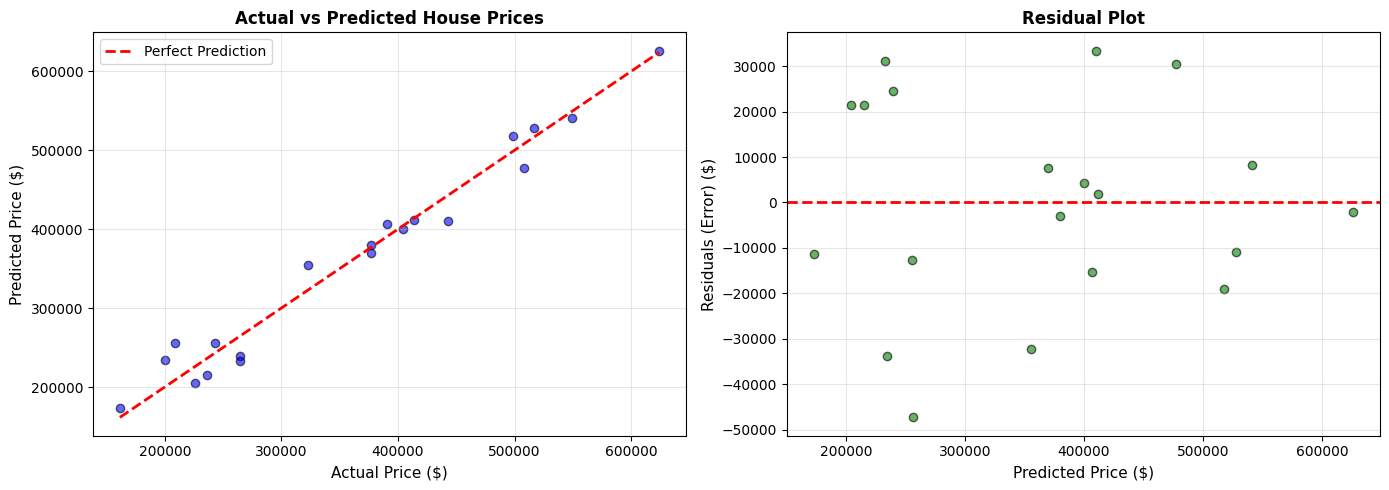

✅ Visualization complete!


In [9]:
# Step 8: Visualize Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title('Actual vs Predicted House Prices', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Prediction Errors)
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='green', edgecolors='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1].set_ylabel('Residuals (Error) ($)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


In [10]:
# Step 9: Make Predictions on New Houses (Real-World Usage)
print("🏠 Making predictions on NEW houses (not seen during training):\n")

# New house 1: 2000 sq ft, 3 bedrooms, 10 years old
new_house_1 = np.array([[2000, 3, 10]])
price_1 = model.predict(new_house_1)[0]
print(f"House 1: 2000 sq ft, 3 bedrooms, 10 years old")
print(f"  Predicted Price: ${price_1:,.2f}\n")

# New house 2: 3500 sq ft, 5 bedrooms, 2 years old
new_house_2 = np.array([[3500, 5, 2]])
price_2 = model.predict(new_house_2)[0]
print(f"House 2: 3500 sq ft, 5 bedrooms, 2 years old")
print(f"  Predicted Price: ${price_2:,.2f}\n")

# New house 3: 1200 sq ft, 2 bedrooms, 30 years old
new_house_3 = np.array([[1200, 2, 30]])
price_3 = model.predict(new_house_3)[0]
print(f"House 3: 1200 sq ft, 2 bedrooms, 30 years old")
print(f"  Predicted Price: ${price_3:,.2f}")

print("\n" + "="*50)
print("🎉 MACHINE LEARNING PIPELINE COMPLETE!")
print("="*50)


🏠 Making predictions on NEW houses (not seen during training):

House 1: 2000 sq ft, 3 bedrooms, 10 years old
  Predicted Price: $341,767.66

House 2: 3500 sq ft, 5 bedrooms, 2 years old
  Predicted Price: $594,454.68

House 3: 1200 sq ft, 2 bedrooms, 30 years old
  Predicted Price: $205,260.39

🎉 MACHINE LEARNING PIPELINE COMPLETE!


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
